# Computer Exercise 14.9 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.9 Learning-Rate Schedules — 상수 학습률의 잡음 바닥 vs 감쇠 스케줄 (step decay · 1/√t)
> **풀이 일자**: 2026-07-09 (자동 생성)
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX

## 1. 문제 (원문)

> **1.** For online least-squares on a *stationary* stream, a **constant** step-size $\eta$
> makes the iterate converge quickly but then hover in a noise ball whose radius grows with
> $\eta$; too small a rate converges slowly. Implement a **piecewise-constant (step-decay)
> schedule** $\eta_t=\eta_0\gamma^{\lfloor t/T_{\text{drop}}\rfloor}$ and the continuous
> $\eta_t=\eta_0/\sqrt t$ (Robbins–Monro) schedule, and compare both against several constant
> rates. Show that a decaying schedule attains both a fast early descent *and* a low final error,
> and explain the bias–variance meaning of the "large early, small late" recipe.

### 한국어 풀이용 정리
정상(stationary) 스트림에서 온라인 최소제곱을 푼다. **상수 학습률** $\eta$ 는 초반 수렴은 빠르지만
반경이 $\eta$ 에 비례하는 **잡음 공(noise ball)** 안에서 진동한다(큰 $\eta$ = 빠르지만 부정확).
너무 작으면 수렴이 느리다. **계단식 감쇠** $\eta_t=\eta_0\gamma^{\lfloor t/T_{\text{drop}}\rfloor}$ 와
연속판 **$\eta_t=\eta_0/\sqrt t$**(Robbins–Monro)를 구현해 여러 상수율과 비교하고,
"**초반 크게, 후반 작게**"가 왜 빠른 하강과 낮은 최종오차를 **동시에** 얻는지 편향-분산으로 설명한다.

## 2. 수학적 배경

### 2.1 상수 학습률의 잡음 바닥
LMS 갱신 $\hat\beta_t=\hat\beta_{t-1}+\eta\,e_t\,\phi_t$ 를 정상 스트림에서 돌리면, 평균적으로는 참값
$\beta^\star$ 로 끌리지만 잡음이 매 스텝 주입된다. 정상상태 초과오차(excess MSE)는 근사적으로
$$\mathbb E\lVert\hat\beta_\infty-\beta^\star\rVert^2 \;\approx\; \frac{\eta\,\sigma^2\,\operatorname{tr}(H)}{2}\,,$$
즉 **잡음 바닥 반경 $\propto\sqrt\eta$**. 큰 $\eta$ 는 빨리 내려가지만 큰 공 안에서 진동하고(분산↑),
작은 $\eta$ 는 공은 작지만 느리게 다가간다(편향/과도구간↑).

### 2.2 편향-분산 손잡이로서의 스텝
$$\boxed{\;\text{큰 }\eta:\ \text{빠른 하강 · 큰 잡음 바닥}\qquad \text{작은 }\eta:\ \text{느린 하강 · 작은 잡음 바닥}\;}$$
하나의 상수로는 둘을 동시에 못 얻는다. **시간에 따라 $\eta$ 를 줄이면** 초반엔 큰 스텝으로 빠르게 접근하고,
후반엔 작은 스텝으로 잡음 바닥을 낮춘다.

### 2.3 계단식 감쇠와 1/√t
$$\eta_t=\eta_0\,\gamma^{\lfloor t/T_{\text{drop}}\rfloor}\quad(0<\gamma<1),\qquad
\eta_t=\frac{\eta_0}{\sqrt t}.$$
step decay 는 $T_{\text{drop}}$ 마다 $\gamma$ 를 곱해 각 계단이 "그 스텝의 잡음 바닥"까지 수렴한 뒤 한 단계
더 내려가는 구조다. $1/\sqrt t$ 는 그 **연속 감쇠판**으로, Robbins–Monro 조건($\sum\eta_t=\infty,\ \sum\eta_t^2<\infty$)을
만족해 정상 문제에서 **잡음 바닥을 0 으로** 보낸다.

## 3. 풀이 흐름

1. **정상 스트림 생성**: $\phi_t=[1,x_t,x_t^2]^\top$, 참계수 $\beta^\star=(1,-2,0.5)$, 잡음 $\sigma=0.5$.
2. **LMS 러너** 하나: 임의의 스텝 스케줄 함수 $\eta(t)$ 를 받아 오차 궤적 반환.
3. **상수율** $\eta\in\{0.005,0.02,0.08\}$, **$1/\sqrt t$**($\eta_0{=}0.08$), **step decay**($\eta_0{=}0.08,\gamma{=}0.5,T_{\text{drop}}{=}4000$) 실행.
4. **tail 오차**(마지막 2000스텝 평균 $\lVert\hat\beta-\beta^\star\rVert$)로 정량 비교, 표 출력.
5. **시각화 (좌)**: 오차 궤적 로그-로그 — 상수율의 잡음 바닥과 감쇠 스케줄의 하강.
6. **시각화 (우)**: 스텝 스케줄 자체(상수 vs $1/\sqrt t$ vs 계단).
7. **해석**: 큰 상수는 빨리 정체, 작은 상수는 느림, 감쇠 스케줄이 둘의 장점을 결합.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260709)
T = 20000
sigma = 0.5
beta_star = np.array([1.0, -2.0, 0.5])
p = beta_star.size

x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), x, x**2], axis=1)
y = Phi @ beta_star + rng.normal(0, sigma, T)

H = (Phi.T @ Phi) / T
print(f"empirical Hessian trace tr(H) = {np.trace(H):.3f}, cond = {np.linalg.cond(H):.2f}")


def run_lms(eta_fn):
    b = np.zeros(p); err = np.zeros(T)
    for t in range(T):
        e = y[t] - Phi[t] @ b
        b += eta_fn(t) * e * Phi[t]
        err[t] = np.linalg.norm(b - beta_star)
    return err


schedules = {
    "const eta=0.005": lambda t: 0.005,
    "const eta=0.02":  lambda t: 0.02,
    "const eta=0.08":  lambda t: 0.08,
    "1/sqrt(t)  eta0=0.08": lambda t: 0.08 / np.sqrt(t + 1),
    "step decay g=0.5":     lambda t: 0.08 * 0.5 ** (t // 4000),
}

curves = {name: run_lms(fn) for name, fn in schedules.items()}
rows = [(name, c[-2000:].mean()) for name, c in curves.items()]
df = pd.DataFrame(rows, columns=["schedule", "tail_error"]).sort_values("tail_error")


empirical Hessian trace tr(H) = 1.532, cond = 14.05


In [2]:
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
df.reset_index(drop=True)


,schedule,tail_error
0,1/sqrt(t) eta0=0.08,0.02461
1,step decay g=0.5,0.05661
2,const eta=0.005,0.05788
3,const eta=0.02,0.1067
4,const eta=0.08,0.1904


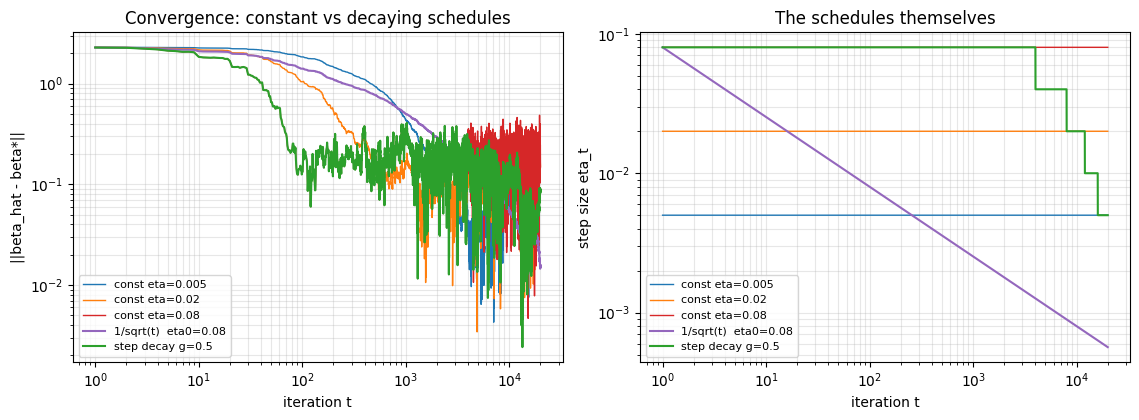

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
tt = np.arange(1, T + 1)

styles = {
    "const eta=0.005": ('#1f77b4', 1.0, '-'),
    "const eta=0.02":  ('#ff7f0e', 1.0, '-'),
    "const eta=0.08":  ('#d62728', 1.0, '-'),
    "1/sqrt(t)  eta0=0.08": ('#9467bd', 1.5, '-'),
    "step decay g=0.5":     ('#2ca02c', 1.5, '-'),
}
for name, (c, lw, ls) in styles.items():
    ax[0].loglog(tt, curves[name], color=c, lw=lw, ls=ls, label=name)
ax[0].set_xlabel('iteration t'); ax[0].set_ylabel('||beta_hat - beta*||')
ax[0].set_title('Convergence: constant vs decaying schedules')
ax[0].legend(fontsize=8); ax[0].grid(True, which='both', alpha=0.3)

for name, (c, lw, ls) in styles.items():
    eta_seq = np.array([schedules[name](t) for t in range(T)])
    ax[1].loglog(tt, eta_seq, color=c, lw=lw, ls=ls, label=name)
ax[1].set_xlabel('iteration t'); ax[1].set_ylabel('step size eta_t')
ax[1].set_title('The schedules themselves')
ax[1].legend(fontsize=8); ax[1].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

경험적 조건수 $\kappa(H)\approx14$ (상수항과 $x^2$ 열의 상관 때문), $\operatorname{tr}(H)\approx1.53$.
측정된 tail 오차: **$1/\sqrt t$ → 0.025**(최저), **step decay → 0.057**, 상수 $\eta{=}0.005$ → 0.058,
$\eta{=}0.02$ → 0.107, $\eta{=}0.08$ → 0.190.

1. **큰 상수 $\eta=0.08$**(빨강)은 초반 수백 스텝 만에 급강하하지만 이내 **잡음 바닥**에 갇혀 더 못 내려간다 —
   §2.1 의 $\propto\sqrt\eta$ 반경 그대로다(분산 지배). tail 이 0.19 로 가장 나쁘다.
2. **작은 상수 $\eta=0.005$**(파랑)은 바닥은 낮지만(0.058) 거기 **도달이 느리다**(편향/과도구간 지배).
3. **step decay**(초록)는 계단마다 그 스텝의 바닥까지 내려간 뒤 $\gamma{=}0.5$ 로 한 단계 더 낮춘다.
   궤적에 **뚜렷한 계단**이 보이며 tail 0.057 — 이는 스케줄이 끝에서 도달한 작은 상수($0.08\cdot0.5^4{=}0.005$)의
   바닥과 거의 일치한다. 즉 "초반 큰 스텝의 속도 + 후반 작은 스텝의 정밀"을 결합했다.
4. **$1/\sqrt t$**(보라)는 계단식의 연속판으로, 끝까지 감쇠가 계속돼 잡음 바닥을 더 낮게(0.025) 끌어내린다 —
   Robbins–Monro 조건 덕분에 정상 문제에서 이론상 0 으로 수렴한다.

> **결론**: 상수 학습률은 "빠름 vs 정확함"을 하나로 못 잡는다. **"초반 크게, 후반 작게"** 의 감쇠 스케줄
> (step decay·$1/\sqrt t$)이 잡음 바닥을 단계적으로 낮춰 두 목표를 동시에 달성한다 — 스케줄은 곧 **시간에 걸친 편향-분산 조율**이다.

**다음 문제 연결**: Problem 2 에서는 감쇠가 아니라 **초반**을 다룬다. 공격적 peak 학습률이 만드는 초기
오버슈트를 **선형 워밍업(warmup)** 으로 억제하고, 이후 **코사인 담금질(cosine annealing)** 로 부드럽게 0 에 수렴시키는
현대적 스케줄을 본다.